# CS 171 — Phishing Hostname Detection
## Checkpoint 1: baseline + multiple model families

**Runtime → Change runtime type → T4 GPU** before running anything.

Trains, on the hostname-level splits:
0. Majority-class baseline
1. Logistic regression (linear)
2. Random forest (tree)
3. MLP (neural net, GPU)
4. Char-BiLSTM (recurrent, GPU)

All preprocessing is fit on **train only**. Evaluation is on **val only** —
the test split stays sealed until the final report.

## 1. Setup

In [1]:
import os, sys, time, random, json
import numpy as np

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader || echo "NO GPU — switch runtime type!"

Tesla T4, 15360 MiB


## 2. Get the code from GitHub

The repo holds code only. The dataset is regenerated by running the
preprocessing pipeline, so this notebook reproduces every result end to end
from the original Kaggle source (requirement 12).

In [2]:
# EDIT: your repo URL
REPO_URL  = 'https://github.com/kbhagra/cs-171project'
REPO_NAME = REPO_URL.rstrip('/').split('/')[-1].replace('.git', '')

%cd /content
!rm -rf {REPO_NAME}
!git clone -q {REPO_URL}

PROJ = f'/content/{REPO_NAME}'
os.chdir(PROJ)
sys.path.insert(0, PROJ)

!pip install -q tldextract kagglehub

print('cloned into', os.getcwd())
!ls

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.9 MB/s eta 0:00:00
cloned into /content/cs-171project
build_hostname_dataset.py	  inspect_data.py  test_normalize.py
CS171_phishing_checkpoint1.ipynb  prep_data.py	   url_normalizer.py
features.py			  priors.json	   verify_normalizer.py
fit_prior.py			  README.md


### Kaggle credentials

Needed only to download the raw dataset. Put them in Colab Secrets (the key
icon in the left sidebar) as `KAGGLE_USERNAME` and `KAGGLE_KEY`, or upload
your `kaggle.json` when prompted.

Get them from kaggle.com -> Settings -> API -> Create New Token.

In [3]:
def setup_kaggle():
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
        print('credentials loaded from Colab Secrets')
        return True
    except Exception as e:
        print('Secrets not available:', type(e).__name__)
    try:
        from google.colab import files
        print('upload your kaggle.json:')
        up = files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/kaggle.json', 'wb') as fh:
            fh.write(list(up.values())[0])
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        print('kaggle.json installed')
        return True
    except Exception as e:
        print('upload failed:', e)
        return False

HAVE_SPLITS = os.path.exists('data/hosts/train.csv')
print('splits already in repo:', HAVE_SPLITS)
if not HAVE_SPLITS:
    setup_kaggle()

splits already in repo: False
Secrets not available: SecretNotFoundError
upload your kaggle.json:


Saving kaggle.json to kaggle.json
kaggle.json installed


### Regenerate the dataset

Same pipeline you built locally: download -> domain-grouped split ->
hostname-level dedup -> prior fitting. Skipped if the splits are already
present. Takes roughly 5-8 minutes.

In [4]:
import glob

def find_script(*names):
    for n in names:
        if os.path.exists(n):
            return n
    raise FileNotFoundError(f'none of {names} in {os.getcwd()}')

if not HAVE_SPLITS:
    import kagglehub
    raw_dir = kagglehub.dataset_download('harisudhan411/phishing-and-legitimate-urls')
    raw_csv = glob.glob(os.path.join(raw_dir, '*.csv'))[0]
    print('raw file:', raw_csv)

    prep = find_script('prep_data.py', 'prepare_data.py')
    !python {prep} --csv "{raw_csv}" --outdir data/splits
    !python build_hostname_dataset.py --indir data/splits --outdir data/hosts
else:
    print('using splits already in the repo')

!ls -la data/hosts

100%|██████████| 12.5M/12.5M [00:01<00:00, 12.7MB/s]

Extracting files...


raw file: /root/.cache/kagglehub/datasets/harisudhan411/phishing-and-legitimate-urls/versions/1/new_data_urls.csv
loaded 822,010 rows, columns: ['url', 'status']

raw label values: ['0', '1']
treating as phishing: ['0']
treating as benign:   ['1']

SANITY CHECKS -- read these before going further

class balance:
  benign   (label=0): 427,028  (51.9%)
  phishing (label=1): 394,982  (48.1%)

sample URLs by class (verify the labels look right!):

  --- benign ---
    http://www.crestonwood.com/router.php
    http://rgipt.ac.in
    http://www.iracing.com/tracks/gateway-motorsports-park/
    http://www.mutuo.it
    http://vamoaestudiarmedicina.blogspot.com/

  --- phishing ---
    0000111servicehelpdesk.godaddysites.com
    000011accesswebform.godaddysites.com
    00003.online
    0009servicedeskowa.godaddysites.com
    000n38p.wcomhost.com

URL length by class:
       mean   50%   75%     max
label                          
0      46.8  41.0  58.0  1264.0
1      47.4  32.0  51.0  3992.0

f

In [ ]:
if not os.path.exists('priors.json'):
    fitp = find_script('fit_prior.py', 'fit_priors.py')
    !python {fitp} --train data/hosts/train.csv --out priors.json
else:
    print('priors.json already present')

_p = json.load(open('priors.json'))
print('\npriors:', {k: len(v) for k, v in _p.items() if not k.startswith('_')})

In [ ]:
# All artifacts land here and get zipped for download at the end.
OUT = '/content/outputs'
MODELS = f'{OUT}/models'
os.makedirs(MODELS, exist_ok=True)
print('outputs ->', OUT)

## 2. Load data

In [5]:
import pandas as pd
import features as F

F.load_priors('priors.json')

tr = pd.read_csv('data/hosts/train.csv')
va = pd.read_csv('data/hosts/val.csv')

ytr = tr['label'].values
yva = va['label'].values

print(f"train {len(tr):,}  ({ytr.mean():.1%} phishing)")
print(f"val   {len(va):,}  ({yva.mean():.1%} phishing)")
print(f"\nClass imbalance: {ytr.mean():.1%} / {1-ytr.mean():.1%} "
      f"-- addressed below with class_weight='balanced' (requirement 8)")

loaded priors from priors.json (fitted on 273943 train hosts): 85 brands, 23 tokens, 3 risky TLDs, 236 abused hosts
train 273,943  (66.6% phishing)
val   64,143  (69.7% phishing)

Class imbalance: 66.6% / 33.4% -- addressed below with class_weight='balanced' (requirement 8)


## 3. Metrics

Security framing: PR-AUC over ROC-AUC under imbalance, plus **P@95%R**
(precision when the threshold catches 95% of phishing) and **FPR**
(fraction of legitimate sites flagged) — the numbers that decide whether a
detector is deployable.

In [6]:
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)

RESULTS = []

def evaluate(name, y_true, scores, notes=""):
    pred = (scores >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ok = rec >= 0.95
    p95 = prec[ok].max() if ok.any() else 0.0

    row = dict(model=name,
               acc=(tp+tn)/len(y_true),
               precision=precision_score(y_true, pred, zero_division=0),
               recall=recall_score(y_true, pred, zero_division=0),
               f1=f1_score(y_true, pred, zero_division=0),
               roc_auc=roc_auc_score(y_true, scores),
               pr_auc=average_precision_score(y_true, scores),
               p_at_95r=p95,
               fpr=fp/(fp+tn) if (fp+tn) else 0.0,
               tn=tn, fp=fp, fn=fn, tp=tp, notes=notes)
    RESULTS.append(row)

    print(f"\n{name}")
    print(f"  acc {row['acc']:.4f}  prec {row['precision']:.4f}  "
          f"rec {row['recall']:.4f}  F1 {row['f1']:.4f}")
    print(f"  ROC-AUC {row['roc_auc']:.4f}  PR-AUC {row['pr_auc']:.4f}  "
          f"P@95R {p95:.4f}  FPR {row['fpr']:.4f}")
    print(f"  TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
    return row

SCORES = {}   # keep val scores for ROC curves + error analysis

## 4. Model 0 — majority baseline (requirement 4)

In [7]:
majority = int(round(ytr.mean()))
const = np.full(len(yva), float(majority))
evaluate('0_majority', yva, const, 'predicts majority class always')
SCORES['0_majority'] = const

print(f"\nEvery model below must beat accuracy {yva.mean() if majority else 1-yva.mean():.4f}")


0_majority
  acc 0.6970  prec 0.6970  rec 1.0000  F1 0.8214
  ROC-AUC 0.5000  PR-AUC 0.6970  P@95R 0.6970  FPR 1.0000
  TN=0 FP=19,438 FN=0 TP=44,705

Every model below must beat accuracy 0.6970


## 5. Feature extraction (fit on train only)

In [8]:
t0 = time.time()
Ftr = F.extract_frame(tr['host'].astype(str))[F.TRAIN_FEATURE_NAMES]
Fva = F.extract_frame(va['host'].astype(str))[F.TRAIN_FEATURE_NAMES]
print(f"{Ftr.shape[1]} engineered features in {time.time()-t0:.0f}s")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(Ftr)          # FIT ON TRAIN ONLY
Xtr_f = scaler.transform(Ftr)
Xva_f = scaler.transform(Fva)

36 engineered features in 44s


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

t0 = time.time()
vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                      max_features=200_000, min_df=3, sublinear_tf=True)
Xtr_ng = vec.fit_transform(tr['host'].astype(str))   # FIT ON TRAIN ONLY
Xva_ng = vec.transform(va['host'].astype(str))
print(f"{len(vec.vocabulary_):,} n-grams in {time.time()-t0:.0f}s")

from scipy.sparse import hstack, csr_matrix
Xtr_all = hstack([Xtr_ng, csr_matrix(Xtr_f)]).tocsr()
Xva_all = hstack([Xva_ng, csr_matrix(Xva_f)]).tocsr()
print("combined:", Xtr_all.shape)

200,000 n-grams in 21s
combined: (273943, 200036)


## 6. Model 1 — Logistic regression (linear, requirement 5)

In [10]:
from sklearn.linear_model import LogisticRegression

t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0,
                        class_weight='balanced',   # requirement 8
                        random_state=SEED)
lr.fit(Xtr_all, ytr)
s = lr.predict_proba(Xva_all)[:,1]
SCORES['1_logreg'] = s
evaluate('1_logreg', yva, s, f'L2, C=1.0, balanced, {time.time()-t0:.0f}s')


1_logreg
  acc 0.8528  prec 0.9542  rec 0.8286  F1 0.8870
  ROC-AUC 0.9358  PR-AUC 0.9730  P@95R 0.8439  FPR 0.0914
  TN=17,662 FP=1,776 FN=7,663 TP=37,042


{'model': '1_logreg',
 'acc': np.float64(0.8528444257362455),
 'precision': 0.954248029264774,
 'recall': 0.8285874063303881,
 'f1': 0.8869892125522312,
 'roc_auc': np.float64(0.9357798817387075),
 'pr_auc': np.float64(0.9730494629176918),
 'p_at_95r': np.float64(0.8439375273218614),
 'fpr': np.float64(0.0913674246321638),
 'tn': np.int64(17662),
 'fp': np.int64(1776),
 'fn': np.int64(7663),
 'tp': np.int64(37042),
 'notes': 'L2, C=1.0, balanced, 133s'}

In [11]:
# Requirement 7: regularization sweep on the validation split
for C in [0.01, 0.1, 1.0, 10.0]:
    m = LogisticRegression(max_iter=1000, C=C, class_weight='balanced',
                           random_state=SEED)
    m.fit(Xtr_all, ytr)
    sc = m.predict_proba(Xva_all)[:,1]
    print(f"C={C:<6} PR-AUC {average_precision_score(yva, sc):.4f}")

C=0.01   PR-AUC 0.9441
C=0.1    PR-AUC 0.9654
C=1.0    PR-AUC 0.9730
C=10.0   PR-AUC 0.9702


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Model 2 — Random forest (tree, requirement 5)

In [12]:
from sklearn.ensemble import RandomForestClassifier

t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, n_jobs=-1,
                            class_weight='balanced_subsample',
                            random_state=SEED)
rf.fit(Xtr_f, ytr)          # engineered features only -- interpretable
s = rf.predict_proba(Xva_f)[:,1]
SCORES['2_randomforest'] = s
evaluate('2_randomforest', yva, s, f'300 trees, {time.time()-t0:.0f}s')


2_randomforest
  acc 0.7627  prec 0.8934  rec 0.7489  F1 0.8148
  ROC-AUC 0.8384  PR-AUC 0.9298  P@95R 0.7414  FPR 0.2055
  TN=15,444 FP=3,994 FN=11,226 TP=33,479


{'model': '2_randomforest',
 'acc': np.float64(0.7627176776889139),
 'precision': 0.8934165932804953,
 'recall': 0.7488871490884689,
 'f1': 0.8147922801723089,
 'roc_auc': np.float64(0.8383987072873456),
 'pr_auc': np.float64(0.9297524151775955),
 'p_at_95r': np.float64(0.7413853297489789),
 'fpr': np.float64(0.20547381417841343),
 'tn': np.int64(15444),
 'fp': np.int64(3994),
 'fn': np.int64(11226),
 'tp': np.int64(33479),
 'notes': '300 trees, 102s'}

In [13]:
# Requirement 10: feature importance
imp = sorted(zip(F.TRAIN_FEATURE_NAMES, rf.feature_importances_),
             key=lambda r: -r[1])
print("Top 15 features:")
for n, v in imp[:15]:
    print(f"  {n:<26}{v:.4f}")

Top 15 features:
  entropy                   0.1138
  tld_len                   0.1066
  sld_entropy               0.0942
  longest_consonant_run     0.0792
  vowel_ratio               0.0755
  n_word_chunks             0.0644
  is_cctld                  0.0425
  subdomain_len             0.0382
  sld_len                   0.0341
  n_dots                    0.0328
  digit_ratio               0.0301
  n_digits                  0.0293
  n_labels                  0.0288
  mean_chunk_len            0.0285
  longest_digit_run         0.0285


## 8. Model 3 — MLP (neural net, requirements 5, 6, 11)

Trained on GPU. Training curves recorded for requirement 6.

In [14]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", dev)

BATCH, EPOCHS, LR = 512, 15, 1e-3

Xtr_t = torch.tensor(Xtr_f, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.float32)
Xva_t = torch.tensor(Xva_f, dtype=torch.float32).to(dev)

dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH, shuffle=True)

mlp = nn.Sequential(
    nn.Linear(Xtr_f.shape[1], 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 1),
).to(dev)

# class imbalance -> positive class weight (requirement 8)
pos_w = torch.tensor([(1-ytr.mean())/ytr.mean()], device=dev)
crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=1e-4)

hist = {'train_loss': [], 'val_loss': [], 'val_prauc': []}
t0 = time.time()
for ep in range(EPOCHS):
    mlp.train(); tot = 0.0
    for xb, yb in dl:
        xb, yb = xb.to(dev), yb.to(dev)
        opt.zero_grad()
        loss = crit(mlp(xb).squeeze(1), yb)
        loss.backward(); opt.step()
        tot += loss.item()*len(xb)
    mlp.eval()
    with torch.no_grad():
        logits = mlp(Xva_t).squeeze(1)
        vl = crit(logits, torch.tensor(yva, dtype=torch.float32, device=dev)).item()
        p = torch.sigmoid(logits).cpu().numpy()
    hist['train_loss'].append(tot/len(ytr))
    hist['val_loss'].append(vl)
    hist['val_prauc'].append(average_precision_score(yva, p))
    print(f"epoch {ep+1:2d}  train {hist['train_loss'][-1]:.4f}  "
          f"val {vl:.4f}  PR-AUC {hist['val_prauc'][-1]:.4f}")

mlp_time = time.time()-t0
SCORES['3_mlp'] = p
evaluate('3_mlp', yva, p,
         f'2x hidden, dropout 0.3, {EPOCHS} ep, bs {BATCH}, lr {LR}, '
         f'{mlp_time:.0f}s on {dev}')

device: cuda
epoch  1  train 0.3555  val 0.3239  PR-AUC 0.9259
epoch  2  train 0.3395  val 0.3228  PR-AUC 0.9256
epoch  3  train 0.3350  val 0.3232  PR-AUC 0.9249
epoch  4  train 0.3327  val 0.3181  PR-AUC 0.9288
epoch  5  train 0.3311  val 0.3165  PR-AUC 0.9294
epoch  6  train 0.3296  val 0.3227  PR-AUC 0.9263
epoch  7  train 0.3289  val 0.3201  PR-AUC 0.9270
epoch  8  train 0.3281  val 0.3209  PR-AUC 0.9282
epoch  9  train 0.3277  val 0.3189  PR-AUC 0.9283
epoch 10  train 0.3272  val 0.3193  PR-AUC 0.9286
epoch 11  train 0.3265  val 0.3174  PR-AUC 0.9293
epoch 12  train 0.3262  val 0.3196  PR-AUC 0.9271
epoch 13  train 0.3257  val 0.3187  PR-AUC 0.9284
epoch 14  train 0.3256  val 0.3209  PR-AUC 0.9273
epoch 15  train 0.3251  val 0.3174  PR-AUC 0.9287

3_mlp
  acc 0.7595  prec 0.9223  rec 0.7151  F1 0.8056
  ROC-AUC 0.8409  PR-AUC 0.9287  P@95R 0.7474  FPR 0.1385
  TN=16,745 FP=2,693 FN=12,735 TP=31,970


{'model': '3_mlp',
 'acc': np.float64(0.7594749232184338),
 'precision': 0.9223090903845599,
 'recall': 0.7151325355105693,
 'f1': 0.8056143533917952,
 'roc_auc': np.float64(0.8408632655922439),
 'pr_auc': np.float64(0.9286763386738658),
 'p_at_95r': np.float64(0.7473823141223053),
 'fpr': np.float64(0.1385430599855952),
 'tn': np.int64(16745),
 'fp': np.int64(2693),
 'fn': np.int64(12735),
 'tp': np.int64(31970),
 'notes': '2x hidden, dropout 0.3, 15 ep, bs 512, lr 0.001, 44s on cuda'}

In [16]:
OUT = '/content/outputs'
MODELS = f'{OUT}/models'
os.makedirs(MODELS, exist_ok=True)

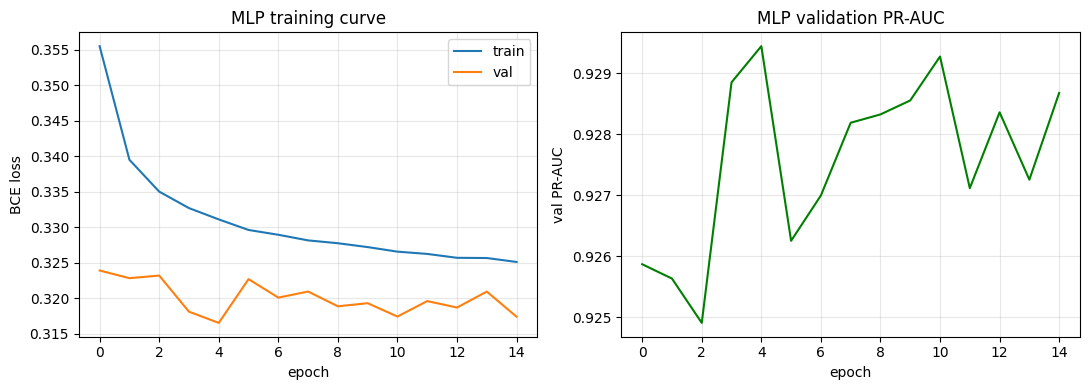

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(hist['train_loss'], label='train')
ax[0].plot(hist['val_loss'], label='val')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('BCE loss')
ax[0].set_title('MLP training curve'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist['val_prauc'], color='green')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val PR-AUC')
ax[1].set_title('MLP validation PR-AUC'); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUT}/fig_mlp_curve.png', dpi=150)
plt.show()

## 9. Model 4 — Character BiLSTM (recurrent, requirements 5, 6, 11)

Reads the hostname character by character. No hand-engineered features —
it learns its own representation.

In [18]:
MAXLEN = 64

chars = sorted(set(''.join(tr['host'].astype(str).tolist())))
stoi = {c: i+1 for i, c in enumerate(chars)}     # 0 = padding
VOCAB = len(stoi) + 1
print(f"vocabulary: {VOCAB} characters")

def encode(hosts):
    out = np.zeros((len(hosts), MAXLEN), dtype=np.int64)
    for i, h in enumerate(hosts):
        h = str(h)[-MAXLEN:]                      # keep the TAIL: TLD + SLD
        for j, c in enumerate(h):
            out[i, j] = stoi.get(c, 0)
    return out

Etr = torch.tensor(encode(tr['host'].tolist()))
Eva = torch.tensor(encode(va['host'].tolist())).to(dev)
print(Etr.shape)

vocabulary: 192 characters
torch.Size([273943, 64])


In [20]:
class CharBiLSTM(nn.Module):
    def __init__(self, vocab, emb=32, hid=64):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hid*2, 1)
    def forward(self, x):
        e = self.emb(x)
        o, _ = self.lstm(e)
        pooled = o.max(dim=1).values         # max-pool over time
        return self.fc(self.drop(pooled)).squeeze(1)


@torch.no_grad()
def predict_batched(model, X, bs=1024):
    """Run inference in chunks -- the full val set at once OOMs the GPU."""
    model.eval()
    out = []
    for i in range(0, len(X), bs):
        out.append(torch.sigmoid(model(X[i:i+bs].to(dev))).cpu().numpy())
    return np.concatenate(out)


torch.manual_seed(SEED)
lstm = CharBiLSTM(VOCAB).to(dev)
opt = torch.optim.Adam(lstm.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)

dl2 = DataLoader(TensorDataset(Etr, ytr_t), batch_size=256, shuffle=True)
EPOCHS_L = 6

hist_l = {'train_loss': [], 'val_prauc': []}
t0 = time.time()
for ep in range(EPOCHS_L):
    lstm.train(); tot = 0.0
    for xb, yb in dl2:
        xb, yb = xb.to(dev), yb.to(dev)
        opt.zero_grad()
        loss = crit(lstm(xb), yb)
        loss.backward(); opt.step()
        tot += loss.item()*len(xb)
    pl = predict_batched(lstm, Eva)
    hist_l['train_loss'].append(tot/len(ytr))
    hist_l['val_prauc'].append(average_precision_score(yva, pl))
    print(f"epoch {ep+1}  train {hist_l['train_loss'][-1]:.4f}  "
          f"val PR-AUC {hist_l['val_prauc'][-1]:.4f}")

lstm_time = time.time()-t0
SCORES['4_bilstm'] = pl
evaluate('4_bilstm', yva, pl,
         f'emb 32, hid 64, {EPOCHS_L} ep, bs 256, {lstm_time:.0f}s on {dev}')

epoch 1  train 0.3091  val PR-AUC 0.9565
epoch 2  train 0.2671  val PR-AUC 0.9610
epoch 3  train 0.2545  val PR-AUC 0.9632
epoch 4  train 0.2472  val PR-AUC 0.9641
epoch 5  train 0.2410  val PR-AUC 0.9646
epoch 6  train 0.2365  val PR-AUC 0.9662

4_bilstm
  acc 0.8164  prec 0.9650  rec 0.7643  F1 0.8530
  ROC-AUC 0.9167  PR-AUC 0.9662  P@95R 0.8047  FPR 0.0637
  TN=18,200 FP=1,238 FN=10,539 TP=34,166


{'model': '4_bilstm',
 'acc': np.float64(0.8163946182747923),
 'precision': 0.9650321997514405,
 'recall': 0.7642545576557432,
 'f1': 0.8529878041168908,
 'roc_auc': np.float64(0.9166834573147314),
 'pr_auc': np.float64(0.9661895189606717),
 'p_at_95r': np.float64(0.8047407912687585),
 'fpr': np.float64(0.0636896800082313),
 'tn': np.int64(18200),
 'fp': np.int64(1238),
 'fn': np.int64(10539),
 'tp': np.int64(34166),
 'notes': 'emb 32, hid 64, 6 ep, bs 256, 50s on cuda'}

## 10. Results table + ROC curves (requirement 9)

In [21]:
res = pd.DataFrame(RESULTS)
cols = ['model','acc','precision','recall','f1','roc_auc','pr_auc','p_at_95r','fpr']
pd.set_option('display.width', 200)
print(res[cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

res.to_csv(f'{OUT}/results_val.csv', index=False)
print("\nsaved results_val.csv")

         model    acc  precision  recall     f1  roc_auc  pr_auc  p_at_95r    fpr
    0_majority 0.6970     0.6970  1.0000 0.8214   0.5000  0.6970    0.6970 1.0000
      1_logreg 0.8528     0.9542  0.8286 0.8870   0.9358  0.9730    0.8439 0.0914
2_randomforest 0.7627     0.8934  0.7489 0.8148   0.8384  0.9298    0.7414 0.2055
         3_mlp 0.7595     0.9223  0.7151 0.8056   0.8409  0.9287    0.7474 0.1385
      4_bilstm 0.8164     0.9650  0.7643 0.8530   0.9167  0.9662    0.8047 0.0637

saved results_val.csv


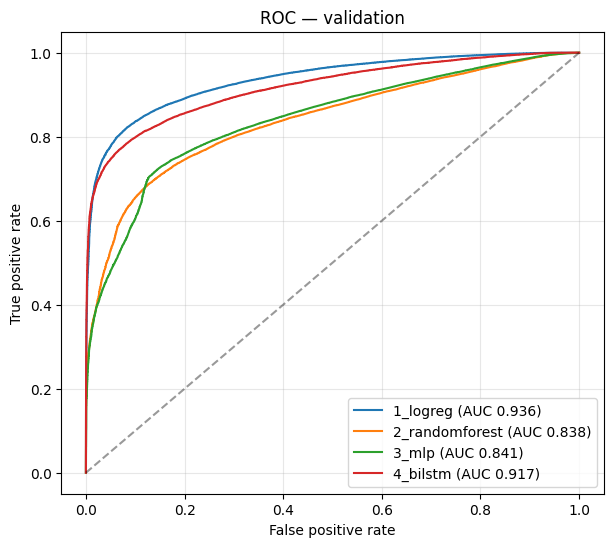

In [22]:
plt.figure(figsize=(7,6))
for name, s in SCORES.items():
    if name.startswith('0_'):
        continue
    fpr, tpr, _ = roc_curve(yva, s)
    plt.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(yva,s):.3f})")
plt.plot([0,1],[0,1],'k--',alpha=.4)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC — validation'); plt.legend(); plt.grid(alpha=.3)
plt.savefig(f'{OUT}/fig_roc.png', dpi=150)
plt.show()

best by PR-AUC: 1_logreg


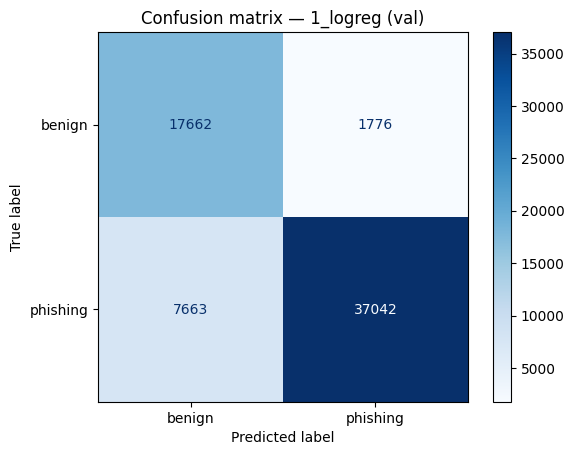

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

best = res.loc[res.pr_auc.idxmax(), 'model']
print("best by PR-AUC:", best)

pred = (SCORES[best] >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    yva, pred, display_labels=['benign','phishing'], cmap='Blues')
plt.title(f'Confusion matrix — {best} (val)')
plt.savefig(f'{OUT}/fig_confusion.png', dpi=150)
plt.show()

## 11. Save artifacts and download

In [24]:
import joblib

joblib.dump(lr,     f'{MODELS}/logreg.joblib')
joblib.dump(rf,     f'{MODELS}/randomforest.joblib')
joblib.dump(vec,    f'{MODELS}/tfidf.joblib')
joblib.dump(scaler, f'{MODELS}/scaler.joblib')
torch.save(mlp.state_dict(),  f'{MODELS}/mlp.pt')
torch.save(lstm.state_dict(), f'{MODELS}/bilstm.pt')
json.dump({'stoi': stoi, 'maxlen': MAXLEN}, open(f'{MODELS}/charmap.json','w'))
json.dump({'mlp': hist, 'lstm': hist_l}, open(f'{MODELS}/history.json','w'))

np.savez(f'{OUT}/val_scores.npz', **SCORES)

print("saved:"); print(os.listdir(MODELS))
print(f"\nRUNTIME NOTE (requirement 11): MLP {mlp_time:.0f}s, "
      f"BiLSTM {lstm_time:.0f}s, device={dev}")

saved:
['randomforest.joblib', 'mlp.pt', 'history.json', 'charmap.json', 'scaler.joblib', 'bilstm.pt', 'logreg.joblib', 'tfidf.joblib']

RUNTIME NOTE (requirement 11): MLP 44s, BiLSTM 50s, device=cuda


In [25]:
# Zip everything and download (or copy into the repo and git push).
!cd /content && zip -qr outputs.zip outputs
print('zip size:', round(os.path.getsize('/content/outputs.zip')/1e6, 1), 'MB')

from google.colab import files
files.download('/content/outputs.zip')

zip size: 275.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Small: figures + results. This is what you need for checkpoint 1.
!cd /content/outputs && zip -qr /content/results_small.zip . -x "models/*"
print('small:', round(os.path.getsize('/content/results_small.zip')/1e6, 1), 'MB')

small: 1.5 MB
